# Introduction to 🤗 Diffusers

![diffusers_library](https://github.com/huggingface/diffusers/raw/main/docs/source/en/imgs/diffusers_library.jpg)

В этом ноутбуке вы обучите свою первую диффузионную модель для **генерации изображений милых бабочек 🦋.** По ходу работы вы познакомитесь с основными компонентами библиотеки 🤗 Diffusers, что даст хорошую базу для более продвинутых применений, которые мы рассмотрим позже в курсе.

Приступим!


## Что Вы Узнаете

В этом ноутбуке вы:

- Увидите мощный кастомный пайплайн диффузионной модели в действии (и узнаете, как создать свою собственную версию)
- Создадите свой мини-пайплайн, выполнив:
  - Повторение основных идей, лежащих в основе диффузионных моделей
  - Загрузку данных с Hugging Face Hub для обучения
  - Изучение того, как мы добавляем шум в данные с помощью планировщика (scheduler)
  - Создание и обучение модели UNet
  - Сборку всех компонентов в рабочий пайплайн
- Отредактируете и запустите скрипт для инициализации более длительных обучений, который обеспечит:
  - Обучение на нескольких GPU с помощью 🤗 Accelerate
  - Логирование экспериментов для отслеживания ключевых метрик
  - Загрузку финальной модели на Hugging Face Hub

❓Если у вас возникнут вопросы, пожалуйста, задавайте их в канале `#diffusion-models-class` на Discord-сервере Hugging Face. Если вы еще не зарегистрированы, вы можете сделать это здесь: https://huggingface.co/join/discord


## Предварительные требования

Перед тем как приступить к работе с ноутбуком, вам следует:

* 📖 Прочитать материалы Юнита 1
* 🤗 Создать аккаунт на Hugging Face Hub. Если вы ещё этого не сделали, вы можете зарегистрироваться здесь: https://huggingface.co/join


## ШАГ 1: НАСТРОЙКА


Запустите следующую ячейку, чтобы установить библиотеку `diffusers`, а также несколько других необходимых зависимостей:


In [2]:
%pip install -qq -U diffusers datasets transformers accelerate ftfy pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 14.0 MB/s eta 0:00:00
ERROR: Operation cancelled by user


Далее перейдите по ссылке https://huggingface.co/settings/tokens и создайте токен доступа с правами на запись, если у вас его ещё нет:


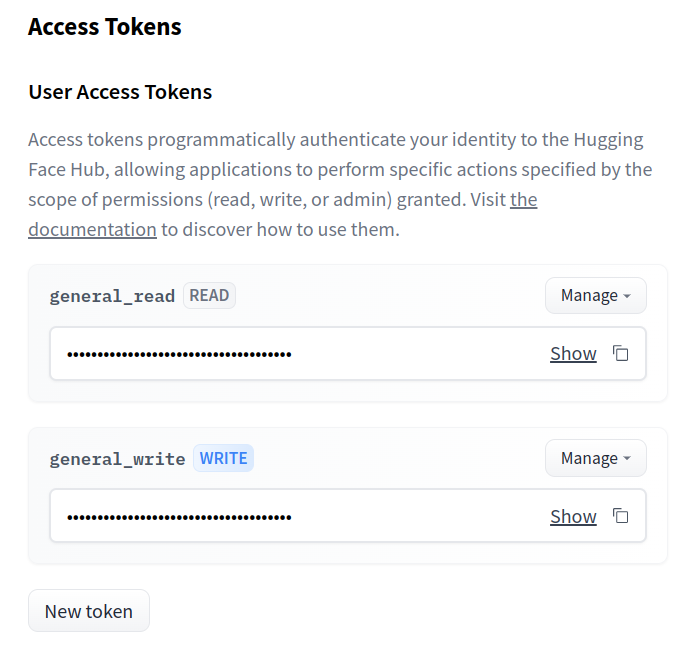

You can login with this token using the command line (`huggingface-cli login`) or by running the following cell:

In [3]:
from huggingface_hub import notebook_login

notebook_login()

Then you need to install Git-LFS to upload your model checkpoints:

In [4]:
%%capture
!sudo apt -qq install git-lfs
!git config --global credential.helper store

Наконец, давайте импортируем библиотеки, которые мы будем использовать, и определим несколько вспомогательных функций, которые пригодятся нам позже в ноутбуке:


In [3]:
import numpy as np
import torch
import torch.nn.functional as F
from matplotlib import pyplot as plt
from PIL import Image


def show_images(x):
    """Given a batch of images x, make a grid and convert to PIL"""
    x = x * 0.5 + 0.5  # Map from (-1, 1) back to (0, 1)
    grid = torchvision.utils.make_grid(x)
    grid_im = grid.detach().cpu().permute(1, 2, 0).clip(0, 1) * 255
    grid_im = Image.fromarray(np.array(grid_im).astype(np.uint8))
    return grid_im


def make_grid(images, size=64):
    """Given a list of PIL images, stack them together into a line for easy viewing"""
    output_im = Image.new("RGB", (size * len(images), size))
    for i, im in enumerate(images):
        output_im.paste(im.resize((size, size)), (i * size, 0))
    return output_im


# Mac users may need device = 'mps' (untested)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Отлично, всё готово!


## Dreambooth: Краткий Взгляд на Будущее


Если вы хотя бы немного следили за соцсетями, связанными с ИИ, за последние несколько месяцев, вы наверняка слышали о Stable Diffusion. Это мощная латентная диффузионная модель, управляемая текстом (не переживайте, мы разберёмся, что всё это значит). Но у неё есть один недостаток: она не знает, как выглядите вы или я, если только мы не достаточно известны, чтобы наши фотографии были повсюду в интернете.

Dreambooth позволяет нам создать собственный вариант модели с дополнительными знаниями о конкретном лице, объекте или стиле. Команда Corridor Crew сняла отличный ролик, где использовала эту технологию для рассказа историй с постоянными персонажами — это отличный пример того, на что способна эта техника:


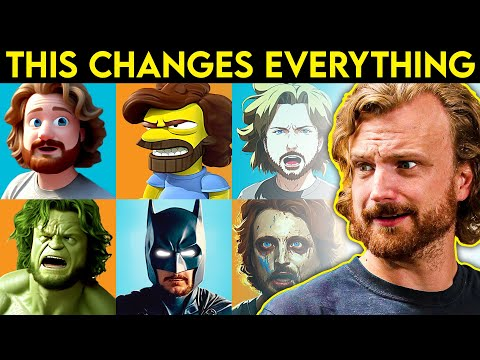

In [6]:
from IPython.display import YouTubeVideo

YouTubeVideo("W4Mcuh38wyM")

Вот пример с использованием [модели](https://huggingface.co/sd-dreambooth-library/mr-potato-head), обученной на 5 фотографиях популярной детской игрушки под названием "Мистер Картофельная Голова" (Mr Potato Head).

Сначала мы загружаем пайплайн. Это действие скачает веса модели и другие данные с Hugging Face Hub. Поскольку для демонстрации в одну строку будет загружено несколько гигабайт данных, вы можете пропустить эту ячейку и просто полюбоваться примером результата!


In [4]:
! pip uninstall torch -y
! pip install torch

Found existing installation: torch 2.6.0+cu124
Uninstalling torch-2.6.0+cu124:
  Successfully uninstalled torch-2.6.0+cu124
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 766.7/766.7 MB 2.4 MB/s eta 0:00:00


In [4]:
from diffusers import StableDiffusionPipeline
import torch

# Check out https://huggingface.co/sd-dreambooth-library for loads of models from the community
model_id = "sd-dreambooth-library/mr-potato-head"

# Load the pipeline
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16).to(
    device
)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--sd-dreambooth-library--mr-potato-head/snapshots/34246b94acd8b96166e8d93eaded001c380a2d4e/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--sd-dreambooth-library--mr-potato-head/snapshots/34246b94acd8b96166e8d93eaded001c380a2d4e/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--sd-dreambooth-library--mr-potato-head/snapshots/34246b94acd8b96166e8d93eaded001c380a2d4e/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--sd-dreambooth-library--mr-potato-head/snapshots/34246b94acd8b96166e8d93eaded001c380a2d4e/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Once the pipeline has finished loading, we can generate images with:

  0%|          | 0/50 [00:00<?, ?it/s]

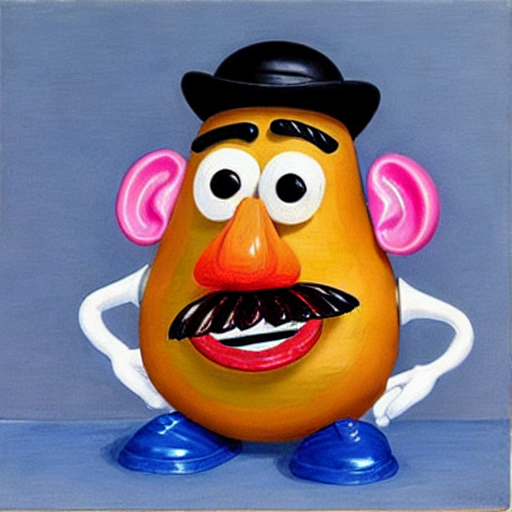

In [5]:
prompt = "an abstract oil painting of sks mr potato head by picasso"
image = pipe(prompt, num_inference_steps=50, guidance_scale=7.5).images[0]
image

**Упражнение:** Попробуйте сами с другими промптами (prompts). Токен `sks` представляет собой уникальный идентификатор нового концепта в этом случае — что произойдёт, если вы его опустите? Вы также можете поэкспериментировать с изменением количества шагов семплирования (насколько низко можно опуститься?) и параметром `guidance_scale`, который определяет, насколько сильно модель будет пытаться соответствовать текстовому описанию.


В этом волшебном пайплайне происходит многое! К концу курса вы будете понимать, как всё это работает. А пока давайте посмотрим, как можно обучить диффузионную модель с нуля.


## MVP (Минимально Жизнеспособный Пайплайн)

Основное API библиотеки 🤗 Diffusers делится на три ключевых компонента:
1. **Pipelines (Пайплайны)**: высокоуровневые классы, предназначенные для быстрого и удобного генерации изображений с использованием популярных предобученных диффузионных моделей.
2. **Models (Модели)**: популярные архитектуры для обучения новых диффузионных моделей, например [UNet](https://arxiv.org/abs/1505.04597).
3. **Schedulers (Планировщики)**: различные методы генерации изображений из шума во время *инференса*, а также для добавления шума к изображениям во время *обучения*.

Пайплайны отлично подходят для конечных пользователей, но если вы проходите этот курс — значит, вам интересно, что происходит "под капотом"! Поэтому в оставшейся части ноутбука мы построим собственный пайплайн, способный генерировать маленькие изображения бабочек. Вот как выглядит финальный результат:


model_index.json:   0%|          | 0.00/180 [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

diffusion_pytorch_model.bin:   0%|          | 0.00/74.3M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/702 [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/267 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--johnowhitaker--ddpm-butterflies-32px/snapshots/ff99059aed185f6158729b8e9f2286c4b9c177f3: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--johnowhitaker--ddpm-butterflies-32px/snapshots/ff99059aed185f6158729b8e9f2286c4b9c177f3.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


  0%|          | 0/1000 [00:00<?, ?it/s]

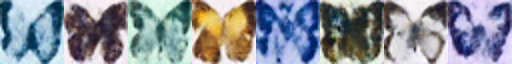

In [6]:
from diffusers import DDPMPipeline

# Load the butterfly pipeline
butterfly_pipeline = DDPMPipeline.from_pretrained(
    "johnowhitaker/ddpm-butterflies-32px"
).to(device)

# Create 8 images
images = butterfly_pipeline(batch_size=8).images

# View the result
make_grid(images)

Возможно, это не так впечатляюще, как пример с DreamBooth, но не забывайте — мы обучаем модель с нуля, используя примерно ~0.0001% данных, которые использовались для обучения Stable Diffusion. К слову об обучении: вспомните из введения в этот юнит, что процесс обучения диффузионной модели выглядит примерно так:

1.   Загружаем изображения из обучающего набора данных  
2.   Добавляем шум в разном количестве  
3.   Передаём зашумлённые изображения в модель  
4.   Оцениваем, насколько хорошо модель справляется с удалением шума  
5.   Используем эту информацию для обновления весов модели и повторяем процесс  

Мы подробно рассмотрим каждый из этих шагов в следующих разделах, пока не получим полностью рабочий цикл обучения. После этого мы изучим, как проводить сэмплирование из обученной модели и как собрать всё в удобный пайплайн для лёгкого распространения


## Шаг 2: Загрузка обучающего датасета

В этом примере мы используем датасет изображений с Hugging Face Hub. А именно — [эту коллекцию из 1000 изображений бабочек](https://huggingface.co/datasets/huggan/smithsonian_butterflies_subset). Это очень маленький датасет, поэтому мы также добавили закомментированные строки с вариантами загрузки более крупных наборов данных.

Если вы хотите использовать свою собственную коллекцию изображений, вы можете воспользоваться закомментированным примером кода для загрузки изображений из папки.


In [8]:
! pip install datasets

  Using cached datasets-3.5.0-py3-none-any.whl.metadata (19 kB)
Using cached datasets-3.5.0-py3-none-any.whl (491 kB)


In [9]:
import torchvision
from datasets import load_dataset
from torchvision import transforms

dataset = load_dataset("huggan/smithsonian_butterflies_subset", split="train")

# Or load images from a local folder
# dataset = load_dataset("imagefolder", data_dir="path/to/folder")

# We'll train on 32-pixel square images, but you can try larger sizes too
image_size = 32
# You can lower your batch size if you're running out of GPU memory
batch_size = 64

# Define data augmentations
preprocess = transforms.Compose(
    [
        transforms.Resize((image_size, image_size)),  # Resize
        transforms.RandomHorizontalFlip(),  # Randomly flip (data augmentation)
        transforms.ToTensor(),  # Convert to tensor (0, 1)
        transforms.Normalize([0.5], [0.5]),  # Map to (-1, 1)
    ]
)


def transform(examples):
    images = [preprocess(image.convert("RGB")) for image in examples["image"]]
    return {"images": images}


dataset.set_transform(transform)

# Create a dataloader from the dataset to serve up the transformed images in batches
train_dataloader = torch.utils.data.DataLoader(
    dataset, batch_size=batch_size, shuffle=True
)

README.md:   0%|          | 0.00/609 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


dataset_infos.json:   0%|          | 0.00/1.65k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/237M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Мы можем получить пакет изображений и просмотреть некоторые из них следующим образом:


X shape: torch.Size([8, 3, 32, 32])


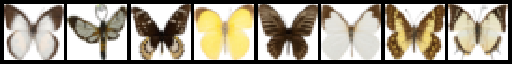

In [10]:
xb = next(iter(train_dataloader))["images"].to(device)[:8]
print("X shape:", xb.shape)
show_images(xb).resize((8 * 64, 64), resample=Image.NEAREST)

Мы используем небольшой датасет с изображениями размером 32 пикселя, чтобы время обучения оставалось разумным в рамках этого ноутбука.


## Шаг 3: Определим Планировщик (Scheduler)

Наш план обучения заключается в том, чтобы взять исходные изображения и добавить к ним шум, а затем передать зашумлённые изображения в модель. Во время инференса мы будем использовать предсказания модели для поэтапного удаления шума. В библиотеке `diffusers` оба этих процесса обрабатываются с помощью **планировщика (scheduler)**.

График добавления шума (noise schedule) определяет, сколько шума добавляется на каждом временном шаге. Вот как мы можем создать планировщик, используя настройки по умолчанию для обучения и сэмплирования по методу 'DDPM' (на основе статьи ["Denoising Diffusion Probabilistic Models"](https://arxiv.org/abs/2006.11239)):


In [11]:
from diffusers import DDPMScheduler

noise_scheduler = DDPMScheduler(num_train_timesteps=1000)

В статье про DDPM описывается процесс "порчи" изображений, при котором на каждом временном шаге (timestep) добавляется небольшое количество шума. Зная $x_{t-1}$ для некоторого шага, мы можем получить следующее (немного более зашумлённое) изображение $x_t$ с помощью формулы:

<br>

$q(\mathbf{x}_t \vert \mathbf{x}_{t-1}) = \mathcal{N}(\mathbf{x}_t; \sqrt{1 - \beta_t} \mathbf{x}_{t-1}, \beta_t\mathbf{I}) \quad
q(\mathbf{x}_{1:T} \vert \mathbf{x}_0) = \prod^T_{t=1} q(\mathbf{x}_t \vert \mathbf{x}_{t-1})$

<br><br>

То есть, мы берём $x_{t-1}$, масштабируем его на $\sqrt{1 - \beta_t}$ и добавляем шум, масштабированный по $\beta_t$. Значения $\beta$ задаются для каждого t согласно определённому расписанию (schedule) и определяют, сколько шума добавляется на каждом шаге.

Но нам не обязательно выполнять эту операцию 500 раз, чтобы получить $x_{500}$. Вместо этого есть формула, которая позволяет сразу получить $x_t$ для любого t, если у нас есть $x_0$:

<br>

$\begin{aligned}
q(\mathbf{x}_t \vert \mathbf{x}_0) &= \mathcal{N}(\mathbf{x}_t; \sqrt{\bar{\alpha}_t} \mathbf{x}_0, {(1 - \bar{\alpha}_t)} \mathbf{I})
\end{aligned}$

<br>

где $\bar{\alpha}_t = \prod_{i=1}^T \alpha_i$, а $\alpha_i = 1 - \beta_i$

<br><br>

Математическая нотация может выглядеть пугающе, но, к счастью, планировщик (scheduler) берёт всё это на себя. Мы можем построить графики $\sqrt{\bar{\alpha}_t}$ (обозначается как `sqrt_alpha_prod`) и $\sqrt{(1 - \bar{\alpha}_t)}$ (обозначается как `sqrt_one_minus_alpha_prod`), чтобы увидеть, как исходное изображение (x) и шум масштабируются и смешиваются на разных временных шагах:


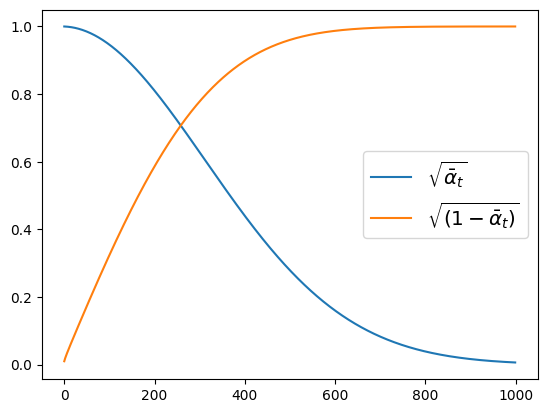

In [12]:
plt.plot(noise_scheduler.alphas_cumprod.cpu() ** 0.5, label=r"${\sqrt{\bar{\alpha}_t}}$")
plt.plot((1 - noise_scheduler.alphas_cumprod.cpu()) ** 0.5, label=r"$\sqrt{(1 - \bar{\alpha}_t)}$")
plt.legend(fontsize="x-large");

**Упражнение:** Вы можете изучить, как изменяется этот график при разных настройках `beta_start`, `beta_end` и `beta_schedule`, просто заменив текущие параметры на одну из закомментированных опций в этом месте:









In [ ]:
# One with too little noise added:
# noise_scheduler = DDPMScheduler(num_train_timesteps=1000, beta_start=0.001, beta_end=0.004)
# The 'cosine' schedule, which may be better for small image sizes:
# noise_scheduler = DDPMScheduler(num_train_timesteps=1000, beta_schedule='squaredcos_cap_v2')

Какой бы планировщик вы ни выбрали, теперь мы можем использовать его для добавления шума в разных количествах с помощью функции `noise_scheduler.add_noise`, например так:

Noisy X shape torch.Size([8, 3, 32, 32])


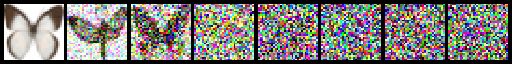

In [13]:
timesteps = torch.linspace(0, 999, 8).long().to(device)
noise = torch.randn_like(xb)
noisy_xb = noise_scheduler.add_noise(xb, noise, timesteps)
print("Noisy X shape", noisy_xb.shape)
show_images(noisy_xb).resize((8 * 64, 64), resample=Image.NEAREST)

Снова рекомендуем поэкспериментировать с различными графиками шума (noise schedules) и параметрами. [Это видео](https://www.youtube.com/watch?v=fbLgFrlTnGU) отлично объясняет некоторые из вышеприведённых математических идей более подробно и служит отличным введением


## ШАГ 4: ОПРЕДЕЛЕНИЕ МОДЕЛИ

Теперь мы переходим к ключевому компоненту: самой модели.

Большинство диффузионных моделей используют архитектуру, являющуюся вариацией [U-net](https://arxiv.org/abs/1505.04597) — и именно её мы будем использовать здесь.

![](https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/unet-model.png)

Вкратце:
- входное изображение проходит через несколько блоков ResNet-слоёв, каждый из которых уменьшает размер изображения в 2 раза;
- затем — через такое же количество блоков, которые снова увеличивают размер (upsampling);
- при этом есть skip-соединения, связывающие признаки (features) на пути уменьшения с соответствующими слоями на пути увеличения.

Ключевая особенность этой модели — она предсказывает изображение того же размера, что и входное. Это как раз то, что нам нужно.

В библиотеке Diffusers есть удобный класс `UNet2DModel`, который создаёт нужную архитектуру на PyTorch.

### 🧠 Аналогия из жизни:
Представьте себе, что вы пытаетесь нарисовать сложную картину.
Сначала вы делаете набросок, убирая детали и фокусируясь на общей форме (это downsampling).
Затем, вспоминая то, что вы уже наметили, вы возвращаетесь к изображению, постепенно добавляя детали (это upsampling).
А чтобы не забыть важные элементы, вы оставляете заметки на полях и сверяетесь с ними во время работы — это и есть skip-соединения, которые помогают восстановить оригинальные особенности изображения.

Давайте создадим U-net для нашего целевого размера изображения.  
Обратите внимание, что `down_block_types` соответствуют блокам понижения разрешения (зелёные на схеме выше), а `up_block_types` — блокам повышения разрешения (красные на схеме):


In [23]:
from diffusers import UNet2DModel

# Create a model
model = UNet2DModel(
    sample_size=image_size,  # the target image resolution
    in_channels=3,  # the number of input channels, 3 for RGB images
    out_channels=3,  # the number of output channels
    layers_per_block=2,  # how many ResNet layers to use per UNet block
    block_out_channels=(64, 128, 128, 256),  # More channels -> more parameters
    down_block_types=(
        "DownBlock2D",  # a regular ResNet downsampling block
        "DownBlock2D",
        "AttnDownBlock2D",  # a ResNet downsampling block with spatial self-attention
        "AttnDownBlock2D",
    ),
    up_block_types=(
        "AttnUpBlock2D",
        "AttnUpBlock2D",  # a ResNet upsampling block with spatial self-attention
        "UpBlock2D",
        "UpBlock2D",  # a regular ResNet upsampling block
    ),
)
model.to(device);

При работе с изображениями более высокого разрешения вы можете увеличить количество блоков понижения и повышения разрешения. При этом, чтобы снизить использование памяти, стоит оставить слои внимания (attention) только на самом нижнем уровне (в "дне" U-образной архитектуры).

Позже мы обсудим, как вы можете экспериментировать с архитектурой модели, чтобы подобрать наилучшие параметры под ваш конкретный случай.


Мы можем проверить, что при передаче пакета данных и случайных временных шагов модель выдаёт результат той же формы, что и входные данные:

In [24]:
with torch.no_grad():
    model_prediction = model(noisy_xb, timesteps).sample
model_prediction.shape

torch.Size([8, 3, 32, 32])

В следующем разделе мы рассмотрим, как обучить эту модель.


## Step 5: Create a Training Loop

Время обучать! Ниже представлен типичный цикл оптимизации в PyTorch: мы проходим по данным батч за батчем и на каждом шаге обновляем параметры модели с помощью оптимизатора — в нашем случае это AdamW с learning rate = 0.0004.

Для каждого батча данных мы выполняем следующие шаги:
- Выбираем случайные временные шаги (timesteps)
- Добавляем шум к данным в соответствии с этими шагами
- Пропускаем зашумлённые данные через модель
- Сравниваем предсказания модели с целевыми значениями (в данном случае — это добавленный шум), используя среднеквадратичную ошибку (MSE) как функцию потерь
- Обновляем параметры модели с помощью `loss.backward()` и `optimizer.step()`

В процессе мы также логируем значения потерь, чтобы потом построить график обучения.

🔔 Примечание: выполнение этого кода занимает около 10 минут — вы можете пропустить эти две ячейки и использовать предобученную модель, если спешите.  
Либо вы можете попробовать ускорить процесс, уменьшив количество каналов в слоях модели (см. выше в определении модели).


[Официальный пример обучения с diffusers](https://colab.research.google.com/github/huggingface/notebooks/blob/main/diffusers/training_example.ipynb) обучает более крупную модель на этом же датасете, но с более высоким разрешением. Это хороший ориентир, если вы хотите посмотреть, как выглядит менее минималистичный (и более полный) цикл обучения.


In [ ]:
# Set the noise scheduler
noise_scheduler = DDPMScheduler(
    num_train_timesteps=1000, beta_schedule="squaredcos_cap_v2"
)

# Training loop
optimizer = torch.optim.AdamW(model.parameters(), lr=4e-4)

losses = []

for epoch in range(30):
    for step, batch in enumerate(train_dataloader):
        clean_images = batch["images"].to(device)
        # Sample noise to add to the images
        noise = torch.randn(clean_images.shape).to(clean_images.device)
        bs = clean_images.shape[0]

        # Sample a random timestep for each image
        timesteps = torch.randint(
            0, noise_scheduler.num_train_timesteps, (bs,), device=clean_images.device
        ).long()

        # Add noise to the clean images according to the noise magnitude at each timestep
        noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)

        # Get the model prediction
        noise_pred = model(noisy_images, timesteps, return_dict=False)[0]

        # Calculate the loss
        loss = F.mse_loss(noise_pred, noise)
        loss.backward(loss)
        losses.append(loss.item())

        # Update the model parameters with the optimizer
        optimizer.step()
        optimizer.zero_grad()

    if (epoch + 1) % 5 == 0:
        loss_last_epoch = sum(losses[-len(train_dataloader) :]) / len(train_dataloader)
        print(f"Epoch:{epoch+1}, loss: {loss_last_epoch}")

/usr/local/lib/python3.11/dist-packages/diffusers/configuration_utils.py:140: FutureWarning: Accessing config attribute `num_train_timesteps` directly via 'DDPMScheduler' object attribute is deprecated. Please access 'num_train_timesteps' over 'DDPMScheduler's config object instead, e.g. 'scheduler.config.num_train_timesteps'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)


Epoch:5, loss: 0.1520406436175108
Epoch:10, loss: 0.12096534296870232
Epoch:15, loss: 0.10040826955810189
Epoch:20, loss: 0.08656799327582121
Epoch:25, loss: 0.07723709288984537


Построив график функции потерь (loss), мы увидим, что модель сначала быстро улучшается, а затем продолжает обучаться, но уже медленнее. Это особенно хорошо заметно, если использовать логарифмическую шкалу, как показано на графике справа:


NameError: name 'losses' is not defined

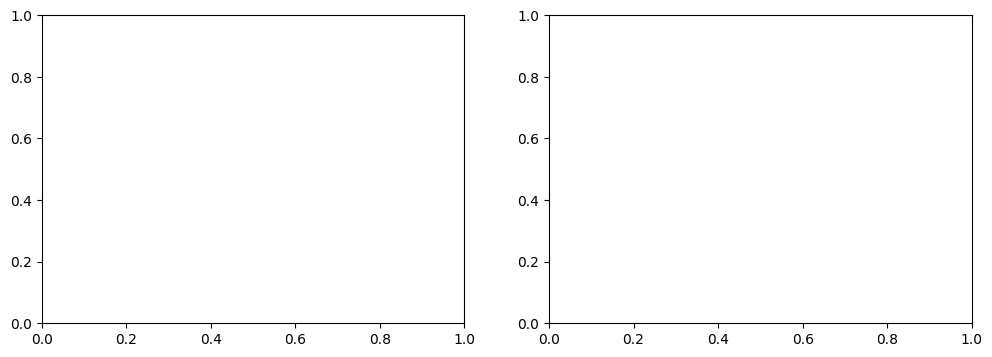

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(losses)
axs[1].plot(np.log(losses))
plt.show()

As an alternative to running the training code above, you can use the model from the pipeline like so:

In [17]:
# Uncomment to instead load the model I trained earlier:
model = butterfly_pipeline.unet

## Шаг 6: Генерация изображений

Как получить изображения с помощью этой модели?


### Вариант 1: Использование пайплайна:

In [19]:
from diffusers import DDPMPipeline

image_pipe = DDPMPipeline(unet=model, scheduler=noise_scheduler)

  0%|          | 0/1000 [00:00<?, ?it/s]

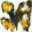

In [20]:
pipeline_output = image_pipe()
pipeline_output.images[0]

Мы можем сохранить пайплайн в корневую папку так:

In [21]:
image_pipe.save_pretrained("my_pipeline")

Смотрим что содержится в папке

In [22]:
!ls my_pipeline/

model_index.json  scheduler  unet


Папки `scheduler` и `unet` содержат всё необходимое для воссоздания этих компонентов. Например, внутри папки `unet` вы найдёте веса модели (`diffusion_pytorch_model.bin`) и файл конфигурации, в котором описана архитектура UNet.


In [ ]:
!ls my_pipeline/unet/

config.json  diffusion_pytorch_model.bin


В совокупности эти файлы содержат всё необходимое для воссоздания пайплайна. Вы можете вручную загрузить их на Hugging Face Hub, чтобы поделиться пайплайном с другими, или перейти к следующему разделу, где показано, как сделать это с помощью API.


### Вариант 2: Написание цикла сэмплирования вручную

Если вы заглянете в метод `forward` пайплайна, вы сможете увидеть, что именно происходит при вызове `image_pipe()`:


In [ ]:
# ??image_pipe.forward

Мы начинаем с случайного шума и проходим по временным шагам планировщика — от самого зашумлённого к наименее зашумлённому, постепенно убирая немного шума на каждом шаге на основе предсказаний модели:


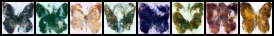

In [ ]:
# Random starting point (8 random images):
sample = torch.randn(8, 3, 32, 32).to(device)

for i, t in enumerate(noise_scheduler.timesteps):

    # Get model pred
    with torch.no_grad():
        residual = model(sample, t).sample

    # Update sample with step
    sample = noise_scheduler.step(residual, t, sample).prev_sample

show_images(sample)

Функция `noise_scheduler.step()` выполняет необходимые математические вычисления для корректного обновления переменной `sample`.

Существует множество методов сэмплирования — в следующем юните мы увидим, как можно заменить используемый сэмплер на другой, чтобы ускорить генерацию изображений с помощью существующих моделей, а также подробнее поговорим о теории сэмплирования в диффузионных моделях.


## Шаг 7: Отправка вашей модели на Hugging Face Hub

В предыдущем примере мы сохранили наш пайплайн в локальную папку. Чтобы загрузить модель на Hugging Face Hub, нам нужно создать репозиторий, куда мы будем загружать файлы.

Имя репозитория определяется из идентификатора модели, который вы хотите присвоить (вы можете заменить `model_name` на любое своё название; главное, чтобы оно содержало ваше имя пользователя — именно это и делает функция `get_full_repo_name()`):


In [ ]:
from huggingface_hub import get_full_repo_name

model_name = "sd-class-butterflies-32"
hub_model_id = get_full_repo_name(model_name)
hub_model_id

'lewtun/sd-class-butterflies-32'

Далее создаём репозиторий модели на 🤗 Hugging Face Hub и загружаем туда нашу модель:


In [ ]:
from huggingface_hub import HfApi, create_repo

create_repo(hub_model_id)
api = HfApi()
api.upload_folder(
    folder_path="my_pipeline/scheduler", path_in_repo="", repo_id=hub_model_id
)
api.upload_folder(folder_path="my_pipeline/unet", path_in_repo="", repo_id=hub_model_id)
api.upload_file(
    path_or_fileobj="my_pipeline/model_index.json",
    path_in_repo="model_index.json",
    repo_id=hub_model_id,
)

'https://huggingface.co/lewtun/sd-class-butterflies-32/blob/main/model_index.json'

Осталось самое последнее — создать красивую карточку модели (model card), чтобы наш генератор бабочек можно было легко найти на Hugging Face Hub.  
(Не стесняйтесь дополнить и отредактировать описание по своему усмотрению!)


In [ ]:
from huggingface_hub import ModelCard

content = f"""
---
license: mit
tags:
- pytorch
- diffusers
- unconditional-image-generation
- diffusion-models-class
---

# Model Card for Unit 1 of the [Diffusion Models Class 🧨](https://github.com/huggingface/diffusion-models-class)

This model is a diffusion model for unconditional image generation of cute 🦋.

## Usage

```python
from diffusers import DDPMPipeline

pipeline = DDPMPipeline.from_pretrained('{hub_model_id}')
image = pipeline().images[0]
image
```
"""

card = ModelCard(content)
card.push_to_hub(hub_model_id)

Теперь, когда модель загружена на Hugging Face Hub, вы можете скачать её откуда угодно, используя метод `from_pretrained()` класса `DDPMPipeline`, вот так:


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

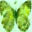

In [ ]:
from diffusers import DDPMPipeline

image_pipe = DDPMPipeline.from_pretrained(hub_model_id)
pipeline_output = image_pipe()
pipeline_output.images[0]

Отлично, это работает!!!

# Масштабирование с помощью 🤗 Accelerate

Этот ноутбук создан в обучающих целях, поэтому я постарался сделать код максимально минималистичным и чистым. Из-за этого мы опустили некоторые вещи, которые могут понадобиться при обучении более крупной модели на большом объёме данных — такие как поддержка нескольких GPU, логирование прогресса и примеров изображений, gradient checkpointing для увеличения batch size, автоматическая загрузка моделей и так далее.

К счастью, большинство этих функций уже реализованы в примере обучающего скрипта [вот здесь](https://github.com/huggingface/diffusers/raw/main/examples/unconditional_image_generation/train_unconditional.py).

Вы можете скачать файл следующим образом:


In [ ]:
!wget https://github.com/huggingface/diffusers/raw/main/examples/unconditional_image_generation/train_unconditional.py

Откройте файл, и вы увидите, где определяется модель и какие параметры доступны для настройки.  
Я запускал этот скрипт с помощью следующей команды:

In [ ]:
# Let's give our new model a name for the Hub
model_name = "sd-class-butterflies-64"
hub_model_id = get_full_repo_name(model_name)
hub_model_id

'lewtun/sd-class-butterflies-64'

In [ ]:
!accelerate launch train_unconditional.py \
  --dataset_name="huggan/smithsonian_butterflies_subset" \
  --resolution=64 \
  --output_dir={model_name} \
  --train_batch_size=32 \
  --num_epochs=50 \
  --gradient_accumulation_steps=1 \
  --learning_rate=1e-4 \
  --lr_warmup_steps=500 \
  --mixed_precision="no"

Как и раньше, давайте загрузим модель на Hugging Face Hub и создадим красивую карточку модели (вы можете отредактировать её по своему усмотрению!):


In [ ]:
create_repo(hub_model_id)
api = HfApi()
api.upload_folder(
    folder_path=f"{model_name}/scheduler", path_in_repo="", repo_id=hub_model_id
)
api.upload_folder(
    folder_path=f"{model_name}/unet", path_in_repo="", repo_id=hub_model_id
)
api.upload_file(
    path_or_fileobj=f"{model_name}/model_index.json",
    path_in_repo="model_index.json",
    repo_id=hub_model_id,
)

content = f"""
---
license: mit
tags:
- pytorch
- diffusers
- unconditional-image-generation
- diffusion-models-class
---

# Model Card for Unit 1 of the [Diffusion Models Class 🧨](https://github.com/huggingface/diffusion-models-class)

This model is a diffusion model for unconditional image generation of cute 🦋.

## Usage

```python
from diffusers import DDPMPipeline

pipeline = DDPMPipeline.from_pretrained('{hub_model_id}')
image = pipeline().images[0]
image
```
"""

card = ModelCard(content)
card.push_to_hub(hub_model_id)

'https://huggingface.co/lewtun/sd-class-butterflies-64/blob/main/README.md'

  0%|          | 0/1000 [00:00<?, ?it/s]

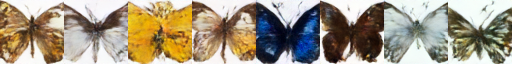

In [ ]:
pipeline = DDPMPipeline.from_pretrained(hub_model_id).to(device)
images = pipeline(batch_size=8).images
make_grid(images)

**Упражнение:** Попробуйте подобрать такие параметры обучения/модели, которые дадут хорошие результаты за минимальное время, и поделитесь своими находками с сообществом. Изучите скрипт — посмотрите, сможете ли вы разобраться в его устройстве, и не стесняйтесь задавать вопросы по любым непонятным моментам.


# Возможности для дальнейшего изучения

Надеемся, этот ноутбук дал вам представление о том, что можно делать с библиотекой 🤗 Diffusers! Вот несколько возможных следующих шагов:

- Попробуйте обучить некондиционированную диффузионную модель на новом датасете — дополнительные баллы, если вы [создадите его сами](https://huggingface.co/docs/datasets/image_dataset). Отличные датасеты изображений для таких задач можно найти в организации [HugGan](https://huggingface.co/huggan) на Hugging Face Hub. Только не забудьте уменьшить разрешение изображений, если не хотите ждать слишком долго, пока модель обучится!
- Попробуйте DreamBooth, чтобы создать собственный кастомизированный пайплайн Stable Diffusion, используя либо [этот Space](https://huggingface.co/spaces/multimodalart/dreambooth-training), либо [этот ноутбук](https://colab.research.google.com/github/huggingface/notebooks/blob/main/diffusers/sd_dreambooth_training.ipynb)
- Измените обучающий скрипт, чтобы поэкспериментировать с различными гиперпараметрами UNet (количество слоёв, число каналов и т.д.), а также с разными графиками шума (noise schedules)
- Посмотрите ноутбук [Diffusion Models from Scratch](https://github.com/huggingface/diffusion-models-class/blob/main/unit1/02_diffusion_models_from_scratch.ipynb), чтобы изучить ключевые идеи этого юнита с другой стороны
